# 04 — Exploratory Data Analysis
Feature distributions, correlation matrix, PCA projection, composite score
vs FotMob player rating sanity check, and seasonal trend charts.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import PCA

DS_DIR = Path('../data/processed/datasets')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

of_train = pd.read_parquet(DS_DIR / 'outfield_train_scaled.parquet')
gk_train = pd.read_parquet(DS_DIR / 'gk_train_scaled.parquet')

print(f'Outfield train: {of_train.shape}')
print(f'GK train:       {gk_train.shape}')


Outfield train: (16913, 87)
GK train:       (1585, 89)


## 1 — Feature distribution histograms (rolling features per position group)

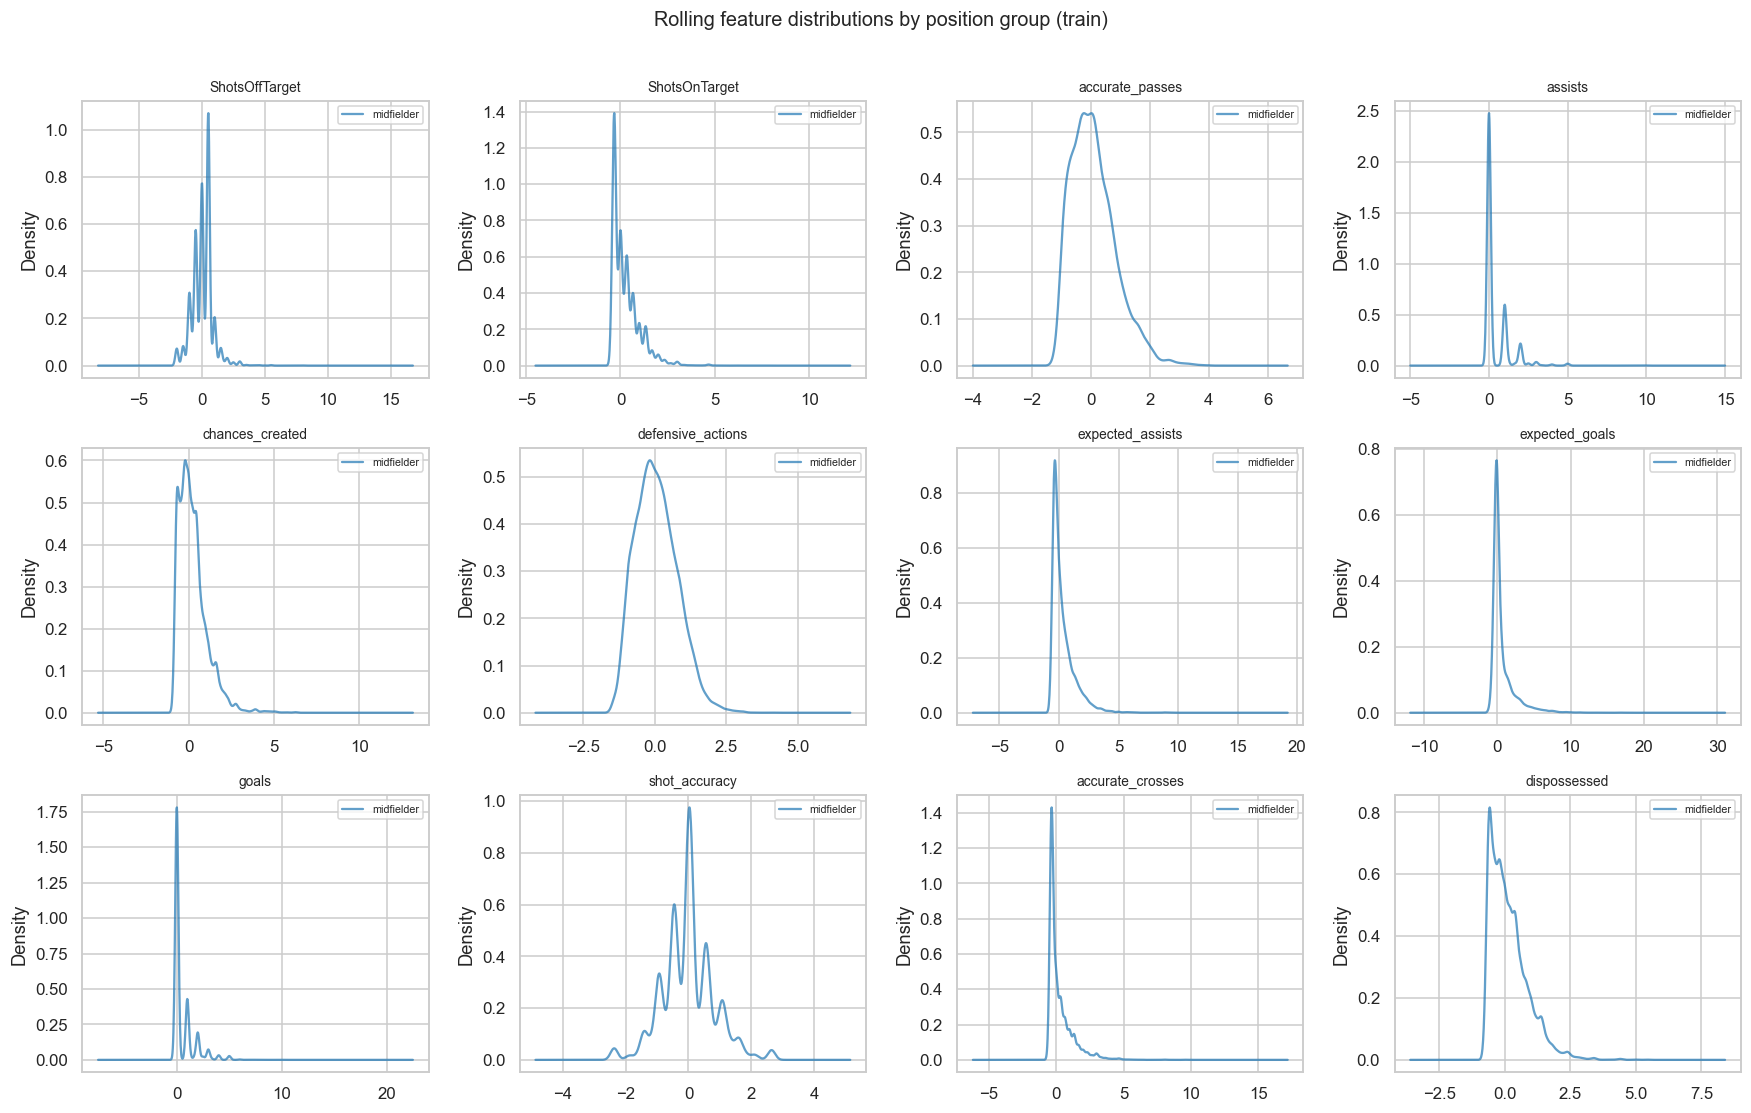

In [2]:
roll_cols = [c for c in of_train.columns if c.startswith('roll5_')][:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(roll_cols):
    ax = axes[i]
    for pos, grp in of_train.groupby('position_group'):
        grp[col].dropna().plot.kde(ax=ax, label=pos, alpha=0.7)
    ax.set_title(col.replace('roll5_', ''), fontsize=9)
    ax.set_xlabel('')
    ax.legend(fontsize=7)

for ax in axes[len(roll_cols):]:
    ax.set_visible(False)

plt.suptitle('Rolling feature distributions by position group (train)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


## 2 — Correlation matrix (top rolling features)

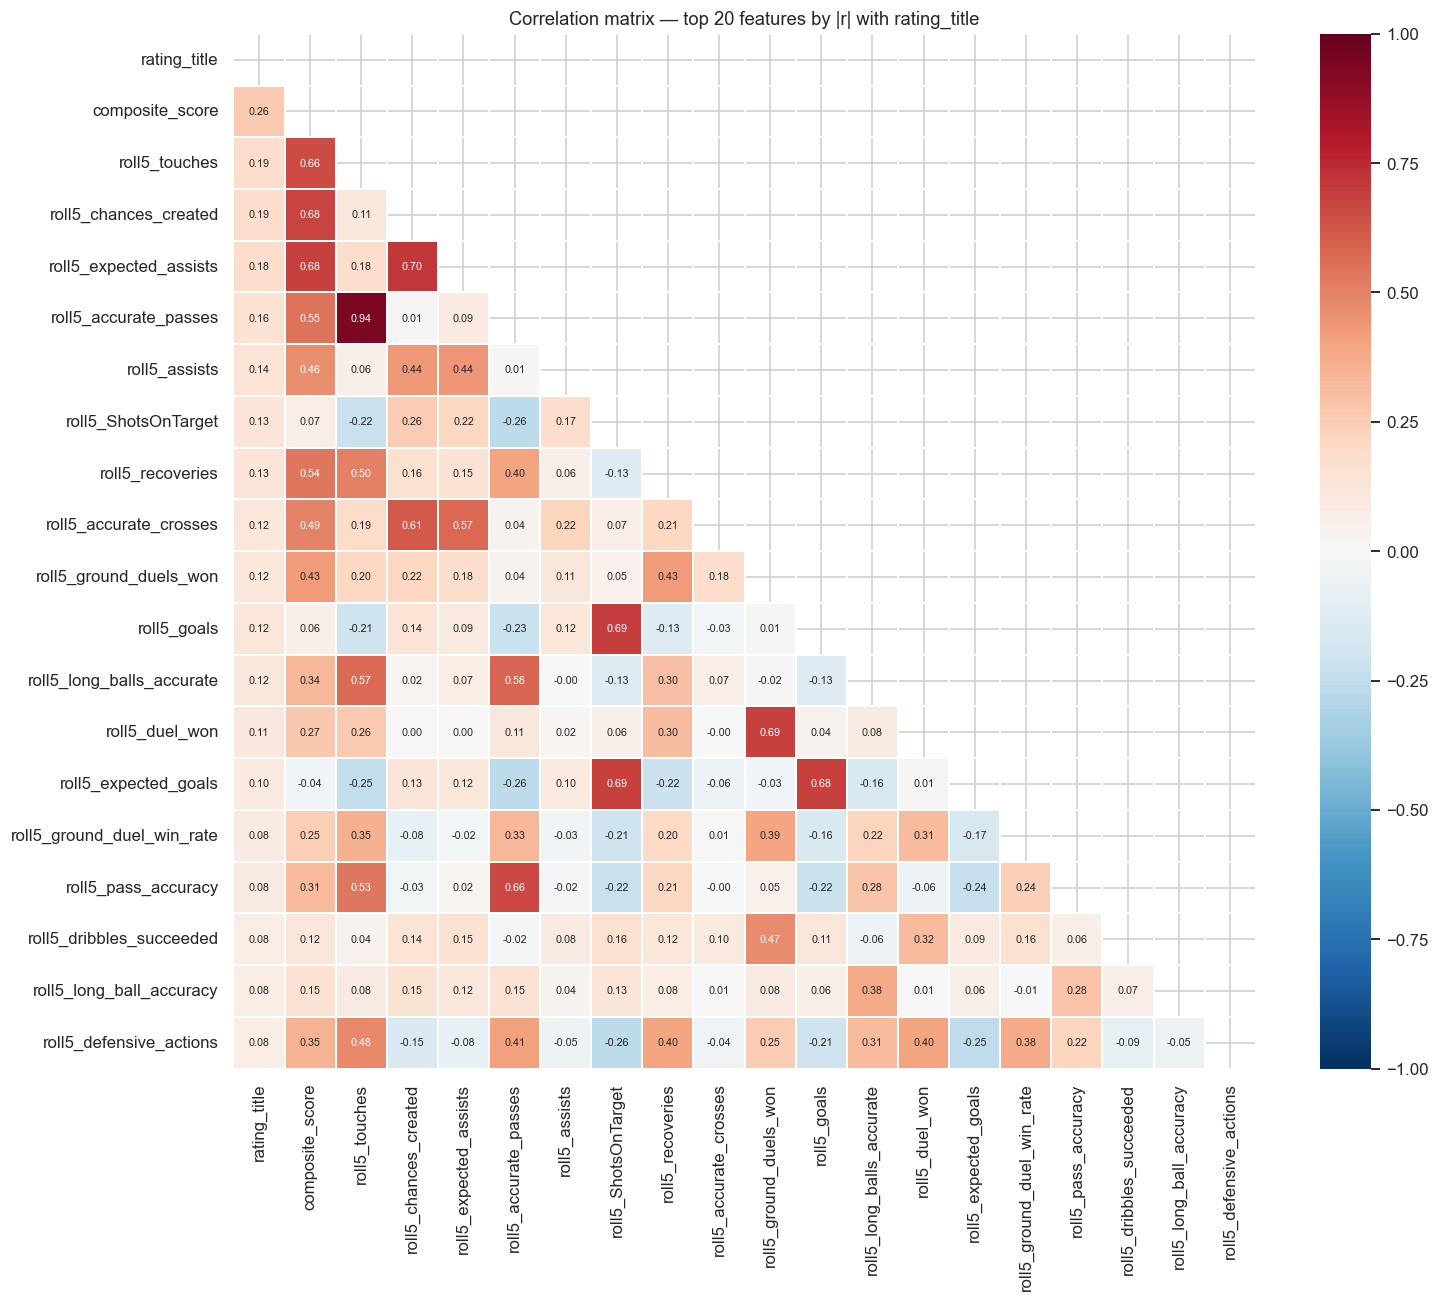

Pairs with |r| > 0.7:
  roll5_chances_created  ↔  roll5_expected_assists  r=0.704
  roll5_accurate_passes  ↔  roll5_touches  r=0.939


In [3]:
roll_cols_all = [c for c in of_train.columns if c.startswith('roll5_')]
corr = of_train[roll_cols_all + ['composite_score', 'rating_title']].corr()

# Show top 20 features most correlated with rating_title
top_corr_cols = corr['rating_title'].abs().sort_values(ascending=False).head(20).index.tolist()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr.loc[top_corr_cols, top_corr_cols], dtype=bool))
sns.heatmap(
    corr.loc[top_corr_cols, top_corr_cols],
    mask=mask,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.3, ax=ax
)
ax.set_title('Correlation matrix — top 20 features by |r| with rating_title', fontsize=12)
plt.tight_layout()
plt.show()

print('Pairs with |r| > 0.7:')
for c1 in top_corr_cols:
    for c2 in top_corr_cols:
        if c1 < c2 and abs(corr.loc[c1, c2]) > 0.7:
            print(f'  {c1}  ↔  {c2}  r={corr.loc[c1,c2]:.3f}')


## 3 — PCA 2D projection by position group

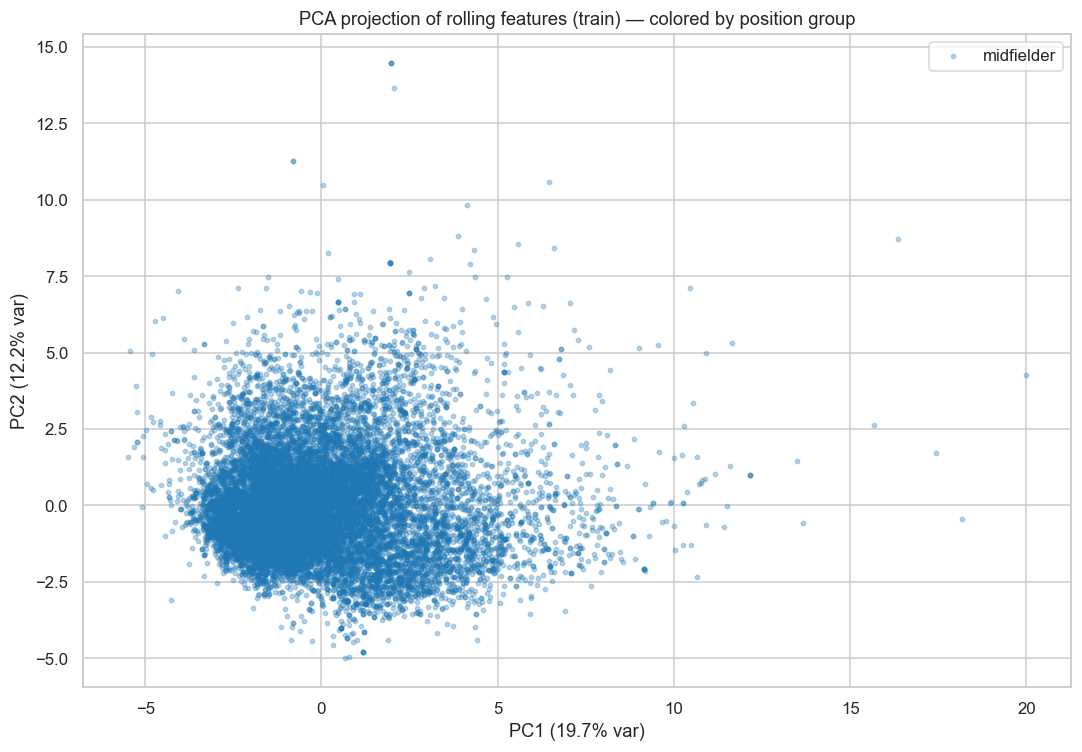

In [4]:
roll_cols_all = [c for c in of_train.columns if c.startswith('roll5_')]
X = of_train[roll_cols_all].fillna(0).values

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X)

pca_df = pd.DataFrame({'PC1': coords[:, 0], 'PC2': coords[:, 1],
                        'position': of_train['position_group'].values})

fig, ax = plt.subplots(figsize=(10, 7))
for pos, grp in pca_df.groupby('position'):
    ax.scatter(grp['PC1'], grp['PC2'], label=pos, alpha=0.3, s=8)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('PCA projection of rolling features (train) — colored by position group')
ax.legend()
plt.tight_layout()
plt.show()


## 4 — Composite score vs FotMob rating_title

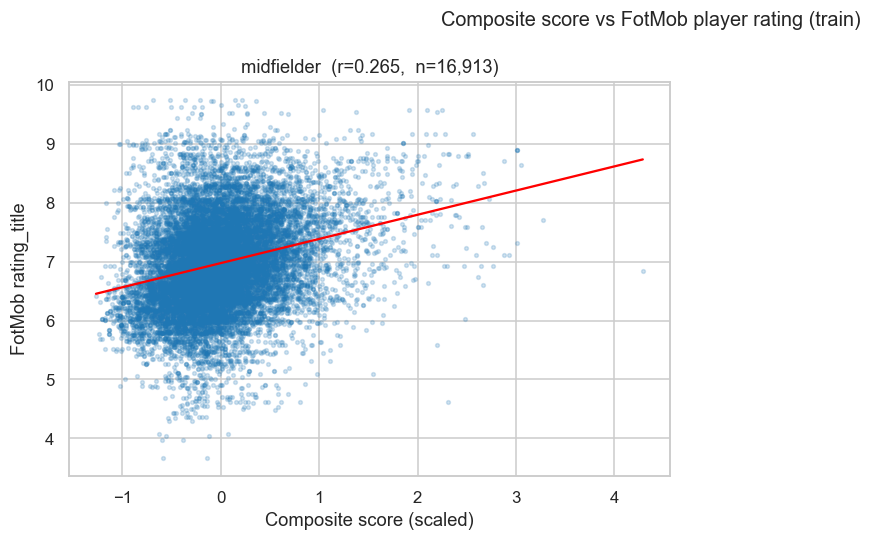

In [5]:
positions = sorted(of_train['position_group'].dropna().unique())
n = len(positions)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(12, 5 * nrows))
axes = np.array(axes).flatten()

for ax, pos in zip(axes, positions):
    sub = of_train[of_train['position_group'] == pos][['composite_score', 'rating_title']].dropna()
    if len(sub) < 2:
        ax.set_visible(False)
        continue
    ax.scatter(sub['composite_score'], sub['rating_title'], alpha=0.2, s=6)
    m, b = np.polyfit(sub['composite_score'], sub['rating_title'], 1)
    x_line = np.linspace(sub['composite_score'].min(), sub['composite_score'].max(), 100)
    ax.plot(x_line, m*x_line + b, color='red', linewidth=1.5)
    r = sub[['composite_score','rating_title']].corr().iloc[0,1]
    ax.set_title(f'{pos}  (r={r:.3f},  n={len(sub):,})')
    ax.set_xlabel('Composite score (scaled)')
    ax.set_ylabel('FotMob rating_title')

for ax in axes[len(positions):]:
    ax.set_visible(False)

plt.suptitle('Composite score vs FotMob player rating (train)', fontsize=13)
plt.tight_layout()
plt.show()

## 5 — Composite score distribution by position and season

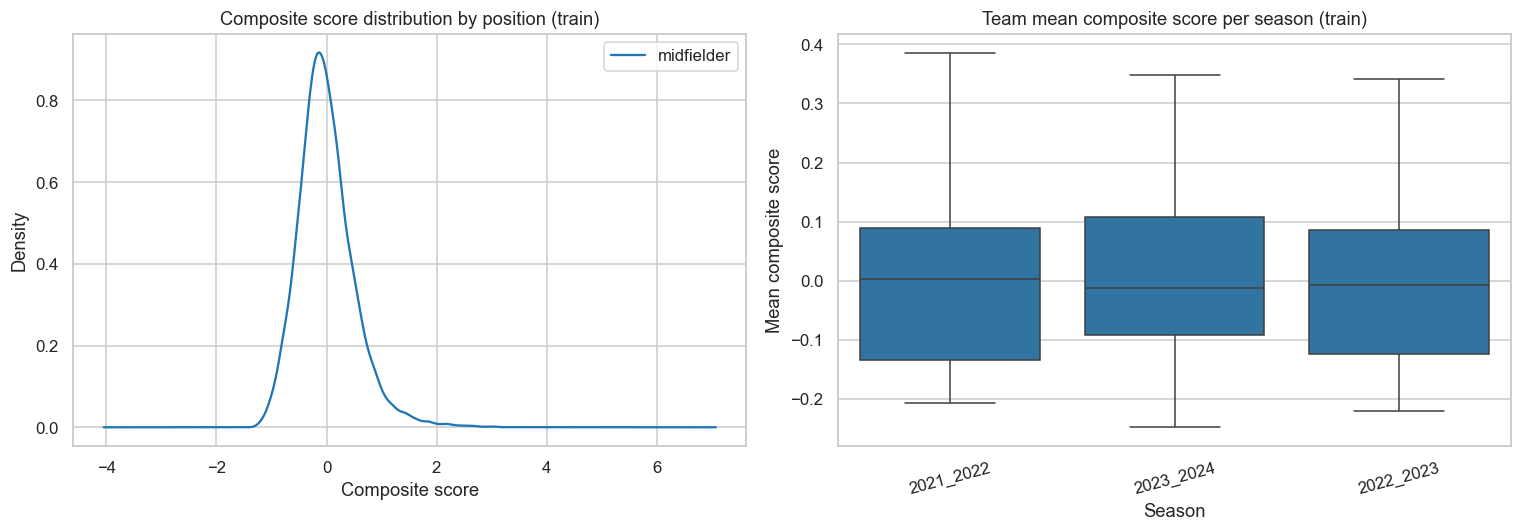


Top 10 teams by mean composite score (train):
team_name
Manchester City           0.345
Manchester United         0.282
Liverpool                 0.275
Chelsea                   0.247
AFC Bournemouth           0.106
Brighton & Hove Albion    0.085
Everton                   0.063
Arsenal                   0.042
Newcastle United          0.029
Aston Villa               0.016


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution per position group
ax = axes[0]
for pos, grp in of_train.groupby('position_group'):
    grp['composite_score'].dropna().plot.kde(ax=ax, label=pos)
ax.set_title('Composite score distribution by position (train)')
ax.set_xlabel('Composite score')
ax.legend()

# Mean composite per team per season
ax = axes[1]
team_season = (
    of_train.groupby(['season', 'team_name'])['composite_score']
    .mean()
    .reset_index()
    .sort_values('composite_score', ascending=False)
)
sns.boxplot(data=team_season, x='season', y='composite_score', ax=ax)
ax.set_title('Team mean composite score per season (train)')
ax.set_xlabel('Season')
ax.set_ylabel('Mean composite score')
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

print()
print('Top 10 teams by mean composite score (train):')
print(
    of_train.groupby('team_name')['composite_score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .round(3)
    .to_string()
)


## 6 — GK composite score sanity check

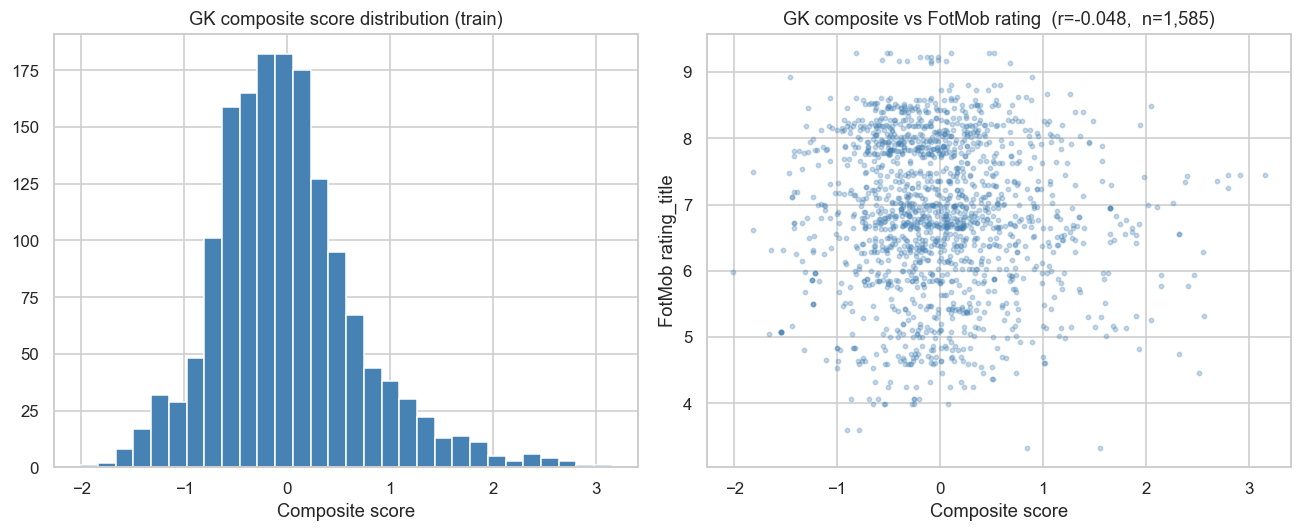

: 

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
gk_train['composite_score'].dropna().hist(bins=30, ax=ax, color='steelblue', edgecolor='white')
ax.set_title('GK composite score distribution (train)')
ax.set_xlabel('Composite score')

ax = axes[1]
valid = gk_train[['composite_score', 'rating_title']].dropna()
ax.scatter(valid['composite_score'], valid['rating_title'], alpha=0.3, s=8, color='steelblue')
r = valid.corr().iloc[0, 1]
ax.set_title(f'GK composite vs FotMob rating  (r={r:.3f},  n={len(valid):,})')
ax.set_xlabel('Composite score')
ax.set_ylabel('FotMob rating_title')

plt.tight_layout()
plt.show()
